# Zajęcie 2. Ćwiczenie: Klasyfikacja/Regresja na danych klinicznych oraz CNN dla obrazów

Ten notatnik **wyjaśnia i realizuje** instrukcję do ćwiczenia laboratoryjnego składającego się z dwóch tematów:

1. **Budowa prostych modeli klasyfikacji i regresji** — rozpoznawanie chorób na podstawie danych klinicznych.
2. **Implementacja sieci neuronowych (CNN)** — tworzenie i trenowanie prostej sieci konwolucyjnej do klasyfikacji obrazów (użyjemy zbioru *sklearn digits* jako *proxy* danych obrazowych medycznych do celów dydaktycznych).

> **Uwaga dot. danych obrazowych:** w warunkach bez dostępu do internetu wykorzystujemy wbudowany zbiór `sklearn.datasets.load_digits` (8×8 pikseli). W środowisku laboratoryjnym możesz zastąpić go własnym zbiorem obrazów medycznych (np. RTG) o analogicznym przepływie pracy.


In [1]:

# --- Importy ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.datasets import load_digits

# TensorFlow/Keras (dla CNN)
from tensorflow import keras
from tensorflow.keras import layers
    
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

print("Środowisko gotowe.")

Środowisko gotowe.


### 1.1 Import danych z `dataset.py`
Wczytujemy ścieżkę `path` z pliku `dataset.py` (Kaggle: `zfturbo/measurements-of-urine-ph`) i ładujemy plik CSV `ph_v1_days.csv`.


In [2]:
from dataset import path as CSV_PATH

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Nie znaleziono pliku datasetu: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print("Wczytano istniejący plik:", CSV_PATH)

display(df.head(10))
print("\nInformacje:")
df.info()
print("\nKształt:", df.shape)


c:\Users\Patryk\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Patryk\.cache\kagglehub\datasets\zfturbo\measurements-of-urine-ph\versions\1
['phlist.csv', 'ph_v1_days.csv', 'prods.csv']
Wczytano istniejący plik: C:\Users\Patryk\.cache\kagglehub\datasets\zfturbo\measurements-of-urine-ph\versions\1\ph_v1_days.csv


,Date,PH_morning,PH_midday,PH_evening,PH_avg,Ailment,Gym,Liquid,Lemon water,Tea(black/green),Fruit tea,Water,Latte,Mineral water (Esentuki - 4),Mineral water (Borjomi),Mineral water (Prolom),Tequila,Red wine,White wine,Strong alcohol,Beer,Morse,Milk,Orange juice,Oatmeal,Pizza with meat,Cheese Pizza,Cheesecakes,Scrambled eggs,Mayonnaise salad,Bread,Meat,Sauce,Cutlet,Sausage,Fish,Sushi,Cod liver,Cheese,Curd,Sour cream,Buckwheat porridge,Noodles with vegetables,Noodles with shrimp,Meat pilaf,Meatless pilaf,Pea soup with meat,Fried vegetables,Pyagse with vegetables,Dumplings with cabbage,Potato dumplings,Zucchini Fritters,Stewed cabbage,Solyanka with meat,Eggplant with cheese,Pasta,Fried potatoes,Cooked Potatoes,Braised Potatoes,Mashed potatoes,Apple Pie,Patty with cabbage,Curd Pie,Cheese Pie,Egg Pie,Potato pie,Meat pie,Khachapuri,The nuts,Pumpkin seeds,Raisins,Dried apricots,Vegetable salad,Eggplant caviar,The vinaigrette,Apple,Peach,Melon,Plum,Tangerines,Pear,Watermelon,Banana,Grapes,Pineapple,Orange,Paste,Kumquat,Ice cream,Cookie,Cake,Bun,Croissant,Chocolate,Candies,Halva,Marshmallow,Red caviar,Jelly
0,06.09.2017,5.41,5.25,5.55,5.40,NaN,NaN,1300,250.0,NaN,600.0,300.0,NaN,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,40.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN,200.0,NaN,100.0,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,07.09.2017,7.06,5.70,5.32,6.03,NaN,1.0,1300,250.0,NaN,600.0,300.0,NaN,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,250.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,NaN,NaN,80.0,NaN,NaN,80.0,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,08.09.2017,6.26,5.75,5.43,5.81,NaN,NaN,1350,250.0,NaN,600.0,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,250.0,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,09.09.2017,5.35,6.85,6.09,6.10,NaN,NaN,2350,250.0,NaN,600.0,400.0,NaN,NaN,250.0,NaN,NaN,350.0,NaN,NaN,500.0,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10.09.2017,6.62,6.34,5.23,6.06,NaN,1.0,1600,250.0,NaN,600.0,300.0,NaN,NaN,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,0.0,200.0,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,NaN,50.0,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,11.09.2017,5.37,6.16,5.48,5.67,NaN,NaN,1700,250.0,NaN,600.0,NaN,NaN,NaN,500.0,NaN,NaN,150.0,NaN,NaN,NaN,200.0,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.0,NaN,NaN,NaN,80.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,180.0,150.0,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,12.09.2017,6.96,6.69,6.50,6.72,NaN,1.0,1550,250.0,NaN,600.0,300.0,NaN,NaN,250.0,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,220.0,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na


Informacje:
<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          212 non-null    str    
 1   PH_morning                    212 non-null    float64
 2   PH_midday                     212 non-null    float64
 3   PH_evening                    210 non-null    float64
 4   PH_avg                        212 non-null    float64
 5   Ailment                       17 non-null     float64
 6   Gym                           62 non-null     float64
 7   Liquid                        212 non-null    int64  
 8   Lemon water                   190 non-null    float64
 9   Tea(black/green)              21 non-null     float64
 10  Fruit tea                     205 non-null    float64
 11  Water                         164 non-null    float64
 12  Latte                         17 non-null     float64
 13  Min

### 1.2 Wstępne przetwarzanie danych
- Obsługa braków, typów i cech pochodnych (np. BMI, jeśli brak).

In [3]:

print("Braki danych na kolumnę:")
print(df.isna().sum())

if "visit_date" in df.columns:
    df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
if "sex" in df.columns:
    df["sex"] = df["sex"].astype("category")

if "bmi" not in df.columns and {"weight_kg", "height_cm"}.issubset(df.columns):
    df["bmi"] = df["weight_kg"] / (df["height_cm"]/100)**2

display(df.describe(include="all"))

Braki danych na kolumnę:
Date             0
PH_morning       0
PH_midday        0
PH_evening       2
PH_avg           0
              ... 
Candies        168
Halva          200
Marshmallow    209
Red caviar     199
Jelly          209
Length: 99, dtype: int64


,Date,PH_morning,PH_midday,PH_evening,PH_avg,Ailment,Gym,Liquid,Lemon water,Tea(black/green),Fruit tea,Water,Latte,Mineral water (Esentuki - 4),Mineral water (Borjomi),Mineral water (Prolom),Tequila,Red wine,White wine,Strong alcohol,Beer,Morse,Milk,Orange juice,Oatmeal,Pizza with meat,Cheese Pizza,Cheesecakes,Scrambled eggs,Mayonnaise salad,Bread,Meat,Sauce,Cutlet,Sausage,Fish,Sushi,Cod liver,Cheese,Curd,Sour cream,Buckwheat porridge,Noodles with vegetables,Noodles with shrimp,Meat pilaf,Meatless pilaf,Pea soup with meat,Fried vegetables,Pyagse with vegetables,Dumplings with cabbage,Potato dumplings,Zucchini Fritters,Stewed cabbage,Solyanka with meat,Eggplant with cheese,Pasta,Fried potatoes,Cooked Potatoes,Braised Potatoes,Mashed potatoes,Apple Pie,Patty with cabbage,Curd Pie,Cheese Pie,Egg Pie,Potato pie,Meat pie,Khachapuri,The nuts,Pumpkin seeds,Raisins,Dried apricots,Vegetable salad,Eggplant caviar,The vinaigrette,Apple,Peach,Melon,Plum,Tangerines,Pear,Watermelon,Banana,Grapes,Pineapple,Orange,Paste,Kumquat,Ice cream,Cookie,Cake,Bun,Croissant,Chocolate,Candies,Halva,Marshmallow,Red caviar,Jelly
count,212,212.000000,212.000000,210.000000,212.000000,17.0,62.0,212.000000,190.000000,21.000000,205.000000,164.000000,17.000000,171.000000,7.000000,21.000000,6.000000,115.000000,10.000000,4.000000,3.0,25.000000,2.000000,24.000000,182.000000,22.000000,3.000000,8.000000,16.00000,17.000000,157.000000,73.000000,6.000000,9.000000,16.000000,6.000000,4.000000,8.000000,57.000000,39.000000,13.000000,8.00000,3.000000,9.0,8.000000,17.000000,6.000000,4.000000,3.0,1.0,38.000000,14.000000,5.000000,2.0,9.000000,12.00000,32.000000,9.000000,22.000000,17.000000,4.0,41.000000,22.000000,4.0,7.000000,4.000000,5.0000,10.000000,130.000000,122.000000,19.000000,124.000000,106.000000,3.000000,10.000000,141.000000,15.000000,5.000000,21.000000,8.000000,14.000000,3.0,58.000000,16.000000,3.000000,1.0,46.000000,5.000000,82.000000,125.00000,51.000000,14.000000,28.000000,19.000000,44.000000,12.000000,3.000000,13.000000,3.000000
unique,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,06.09.2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,6.081462,5.968491,5.879143,5.975000,1.0,1.0,2048.962264,256.315789,352.380952,545.780488,832.774390,294.117647,334.795322,385.714286,726.190476,183.333333,261.391304,422.500000,125.000000,500.0,276.200000,240.000000,202.083333,192.098901,217.227273,286.666667,160.250000,168.50000,117.823529,106.070064,73.808219,45.000000,75.333333,62.687500,81.833333,399.500000,75.250000,43.947368,128.974359,43.846154,112.75000,226.666667,250.0,215.000000,152.235294,205.500000,187.500000,350.0,200.0,234.473684,120.642857,128.000000,150.0,103.111111,81.50000,149.593750,130.444444,141.227273,131.117647,83.5,94.536585,86.681818,106.0,88.571429,59.500000,91.0000,107.800000,25.846154,20.819672,18.578947,23.959677,157.481132,110.000000,144.100000,196.787234,174.733333,

### 1.3 Klasyfikacja: automatyczny wybór celu (dla tego datasetu: `is_safe_zone`)


C:\Users\Patryk\AppData\Local\Temp\ipykernel_20084\2604319042.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include=["object"]).columns:
C:\Users\Patryk\AppData\Local\Temp\ipykernel_20084\2604319042.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui

TARGET_CLS = is_safe_zone
Liczba cech = 98
Accuracy:  0.906
Precision: 0.750
Recall:    0.667
F1-score:  0.706
ROC AUC:   0.876

Raport klasyfikacji:
              precision    recall  f1-score   support

           0      0.933     0.955     0.944        44
           1      0.750     0.667     0.706         9

    accuracy                          0.906        53
   macro avg      0.842     0.811     0.825        53
weighted avg      0.902     0.906     0.903        53



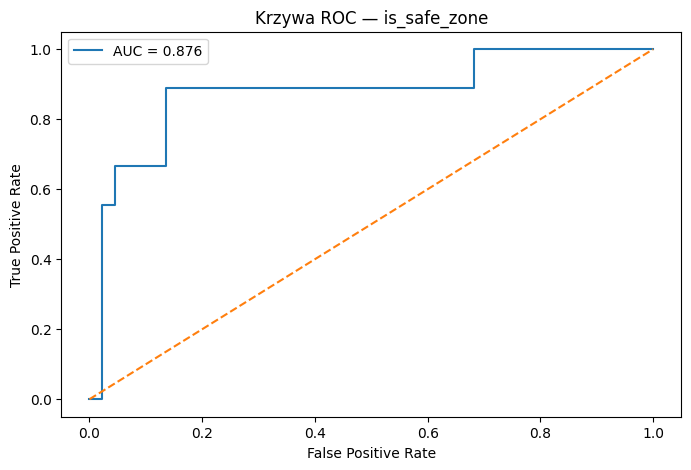

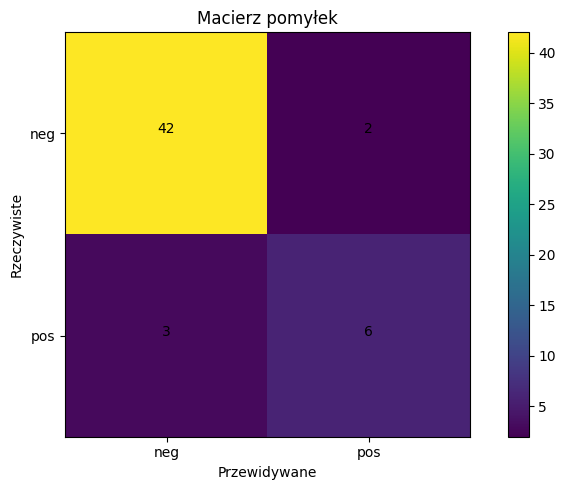

In [4]:
# --- Przygotowanie danych do klasyfikacji (bez twardego 'hypertension') ---
df_cls = df.copy()
df_cls.columns = df_cls.columns.str.strip()

# Usuń kolumny daty (częsty format w tym zbiorze), żeby uprościć modelowanie
date_like_cols = []
for col in df_cls.columns:
    if df_cls[col].dtype == "object":
        parsed = pd.to_datetime(df_cls[col], format="%d.%m.%Y", errors="coerce")
        if parsed.notna().mean() > 0.9:
            date_like_cols.append(col)
if date_like_cols:
    df_cls = df_cls.drop(columns=date_like_cols)

# Cel klasyfikacji
if "hypertension" in df_cls.columns:
    TARGET_CLS = "hypertension"
elif "PH_avg" in df_cls.columns:
    # 1 = bezpieczny zakres pH, 0 = poza zakresem
    df_cls["is_safe_zone"] = ((df_cls["PH_avg"] >= 6.4) & (df_cls["PH_avg"] <= 6.8)).astype(int)
    TARGET_CLS = "is_safe_zone"
else:
    binary_candidates = [
        c for c in df_cls.columns
        if pd.api.types.is_numeric_dtype(df_cls[c]) and df_cls[c].dropna().nunique() == 2
    ]
    if not binary_candidates:
        raise ValueError("Brak kolumny binarnej do klasyfikacji.")
    TARGET_CLS = binary_candidates[0]

drop_for_features = {TARGET_CLS}
if TARGET_CLS == "is_safe_zone" and "PH_avg" in df_cls.columns:
    drop_for_features.add("PH_avg")  # unikamy przecieku informacji

features = [c for c in df_cls.columns if c not in drop_for_features]
X = df_cls[features].copy()
y = df_cls[TARGET_CLS].astype(int)

# Uproszczona obsługa braków/tekstów
for c in X.select_dtypes(include=["object"]).columns:
    X[c] = X[c].fillna("missing")

print(f"TARGET_CLS = {TARGET_CLS}")
print(f"Liczba cech = {len(features)}")

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC AUC:   {auc:.3f}\n")

print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred, digits=3))

fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Krzywa ROC — {TARGET_CLS}")
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Macierz pomyłek")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["neg", "pos"], rotation=0)
plt.yticks(tick_marks, ["neg", "pos"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), horizontalalignment="center")
plt.ylabel("Rzeczywiste")
plt.xlabel("Przewidywane")
plt.tight_layout()
plt.show()


### 1.4 Regresja: automatyczny wybór celu


TARGET_REG = PH_avg
Liczba cech = 98
RMSE: 0.02
R^2 : 0.998


C:\Users\Patryk\AppData\Local\Temp\ipykernel_20084\2978185304.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in Xr.select_dtypes(include=["object"]).columns:
C:\Users\Patryk\AppData\Local\Temp\ipykernel_20084\2978185304.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

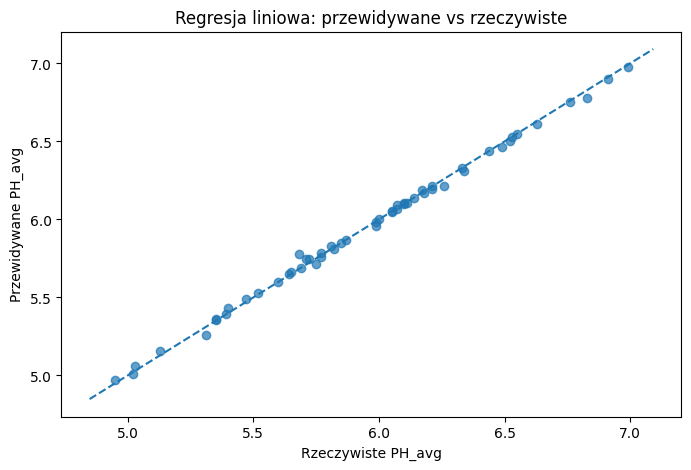

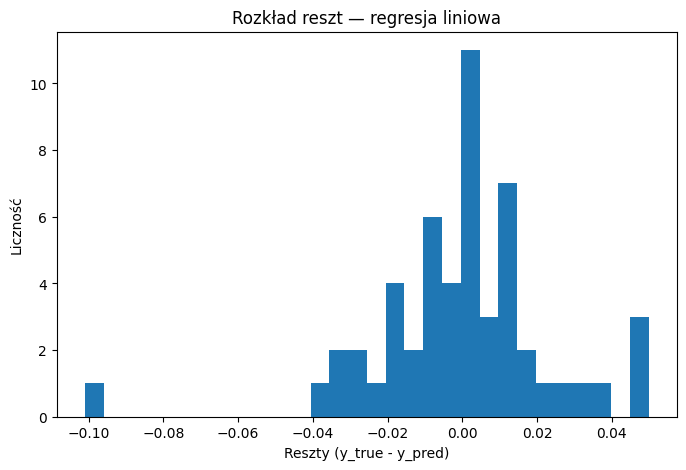

In [5]:
# --- Regresja (bez twardego 'systolic_bp') ---
df_reg = df.copy()
df_reg.columns = df_reg.columns.str.strip()

# Spójnie z klasyfikacją: usuń kolumny daty
date_like_cols_r = []
for col in df_reg.columns:
    if df_reg[col].dtype == "object":
        parsed = pd.to_datetime(df_reg[col], format="%d.%m.%Y", errors="coerce")
        if parsed.notna().mean() > 0.9:
            date_like_cols_r.append(col)
if date_like_cols_r:
    df_reg = df_reg.drop(columns=date_like_cols_r)

if "systolic_bp" in df_reg.columns:
    TARGET_REG = "systolic_bp"
elif "PH_avg" in df_reg.columns:
    TARGET_REG = "PH_avg"
else:
    numeric_cols = [
        c for c in df_reg.columns
        if pd.api.types.is_numeric_dtype(df_reg[c]) and df_reg[c].dropna().nunique() > 10
    ]
    if not numeric_cols:
        raise ValueError("Brak sensownej kolumny numerycznej do regresji.")
    TARGET_REG = numeric_cols[0]

reg_features = [c for c in df_reg.columns if c != TARGET_REG]
Xr = df_reg[reg_features].copy()
yr = df_reg[TARGET_REG].astype(float)

for c in Xr.select_dtypes(include=["object"]).columns:
    Xr[c] = Xr[c].fillna("missing")

print(f"TARGET_REG = {TARGET_REG}")
print(f"Liczba cech = {len(reg_features)}")

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)

num_features_r = Xr_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features_r = Xr_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_r = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_r, num_features_r),
        ("cat", categorical_transformer_r, cat_features_r),
    ]
)

linreg = Pipeline(steps=[
    ("prep", preprocess_r),
    ("reg", LinearRegression())
])

linreg.fit(Xr_train, yr_train)
yr_pred = linreg.predict(Xr_test)

from math import sqrt
rmse = sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2 : {r2:.3f}")

plt.figure()
plt.scatter(yr_test, yr_pred, alpha=0.7)
plt.xlabel(f"Rzeczywiste {TARGET_REG}")
plt.ylabel(f"Przewidywane {TARGET_REG}")
plt.title("Regresja liniowa: przewidywane vs rzeczywiste")
min_v = min(plt.xlim()[0], plt.ylim()[0])
max_v = max(plt.xlim()[1], plt.ylim()[1])
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.show()

residuals = yr_test - yr_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Reszty (y_true - y_pred)")
plt.ylabel("Liczność")
plt.title("Rozkład reszt — regresja liniowa")
plt.show()


In [6]:

digits = load_digits()
X_img = digits.images
y_img = digits.target

X_img = X_img.astype("float32") / 16.0
X_img = np.expand_dims(X_img, axis=-1)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_img, y_img, test_size=0.25, random_state=42, stratify=y_img
)

print("Kształt X_train:", X_train_i.shape)
print("Kształt X_test :", X_test_i.shape)

Kształt X_train: (1347, 8, 8, 1)
Kształt X_test : (450, 8, 8, 1)


### 2.2 Architektura CNN i trenowanie

In [7]:

num_classes = 10
model = keras.Sequential([
    layers.Conv2D(16, (3,3), activation="relu", input_shape=X_train_i.shape[1:]),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train_i, y_train_i,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

c:\Users\Patryk\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2386 - loss: 2.2680 - val_accuracy: 0.2333 - val_loss: 2.2398
Epoch 2/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3528 - loss: 2.1675 - val_accuracy: 0.4741 - val_loss: 2.1038
Epoch 3/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5766 - loss: 1.9771 - val_accuracy: 0.7111 - val_loss: 1.8435
Epoch 4/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7335 - loss: 1.6425 - val_accuracy: 0.8074 - val_loss: 1.4378
Epoch 5/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8106 - loss: 1.2201 - val_accuracy: 0.8148 - val_loss: 1.0095
Epoch 6/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8403 - loss: 0.8544 - val_accuracy: 0.8852 - val_loss: 0.7074
Epoch 7/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8784 - loss: 0.6146 - val_accuracy: 0.8889 - val_loss: 0.5555
Epoch 8/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9053 - loss: 0.4747 - val_accuracy: 0.9074 - val_loss: 0.4697

### 2.3 Ocena i wizualizacja wyników

Test accuracy: 0.880  |  Test loss: 0.462


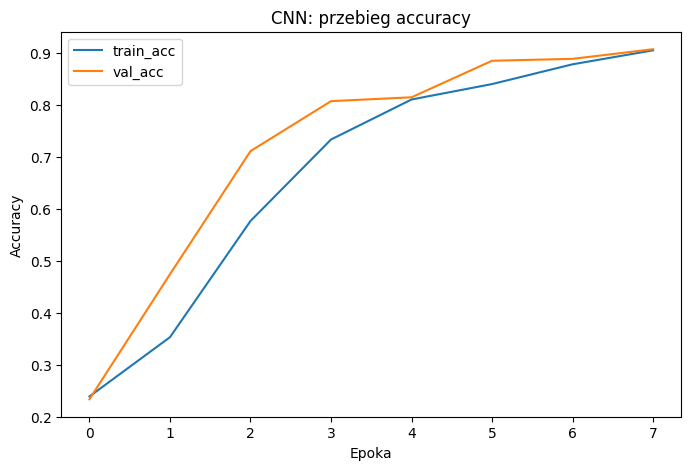

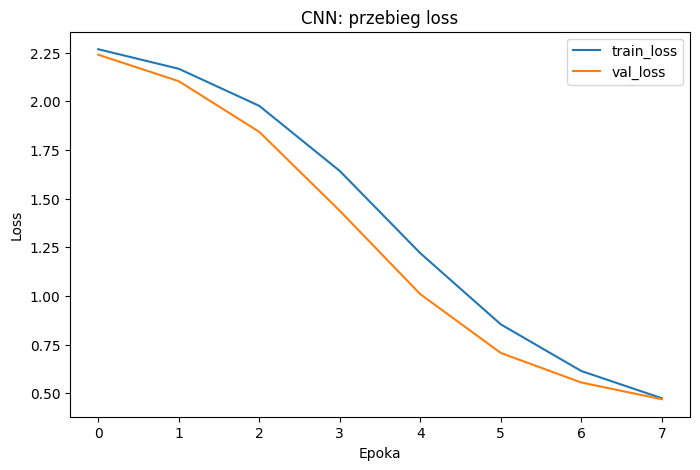

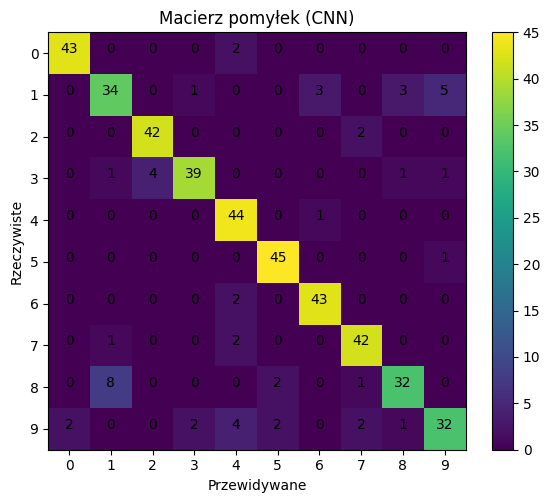

In [8]:

test_loss, test_acc = model.evaluate(X_test_i, y_test_i, verbose=0)
print(f"Test accuracy: {test_acc:.3f}  |  Test loss: {test_loss:.3f}")

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.title("CNN: przebieg accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("CNN: przebieg loss")
plt.legend()
plt.show()

from sklearn.metrics import confusion_matrix
y_pred_i = model.predict(X_test_i, verbose=0).argmax(axis=1)
cm_i = confusion_matrix(y_test_i, y_pred_i)

plt.figure(figsize=(6,5))
plt.imshow(cm_i, interpolation="nearest")
plt.title("Macierz pomyłek (CNN)")
plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
for i in range(cm_i.shape[0]):
    for j in range(cm_i.shape[1]):
        plt.text(j, i, format(cm_i[i, j], "d"),
                 horizontalalignment="center")
plt.ylabel("Rzeczywiste")
plt.xlabel("Przewidywane")
plt.tight_layout()
plt.show()